# AI-Driven Sales Forecasting & Customer Feedback Intelligence System


## 1) Environment Setup

In [1]:
# !pip install pandas numpy matplotlib scikit-learn statsmodels nltk joblib

import os
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()


## 2) Project Configuration

In [2]:

DATA_DIR = Path(".")
SALES_FILE = DATA_DIR / "sales.csv"
REVIEWS_FILE = DATA_DIR / "reviews.csv"

FORECAST_HORIZON = 30
SEASONAL_PERIOD = 7
RANDOM_STATE = 42

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 3) Helper Functions

In [3]:

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_true = np.where(y_true == 0, 1e-8, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    if score <= -0.05:
        return "Negative"
    return "Neutral"

def make_demo_sales(n_days=540, seed=42):
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2024-01-01", periods=n_days, freq="D")
    trend = np.linspace(80, 180, n_days)
    weekly = 15 * np.sin(2 * np.pi * np.arange(n_days) / 7)
    monthly = 8 * np.sin(2 * np.pi * np.arange(n_days) / 30)
    promo = rng.integers(0, 2, size=n_days)
    holiday = ((dates.month == 12) & (dates.day > 20)).astype(int)
    weather = rng.normal(0, 1, n_days)
    noise = rng.normal(0, 8, n_days)

    sales = trend + weekly + monthly + 18 * promo + 10 * holiday - 4 * weather + noise
    sales = np.maximum(25, sales).round(2)

    return pd.DataFrame({
        "date": dates,
        "sales": sales,
        "promo": promo,
        "holiday": holiday,
        "weather_index": weather.round(3)
    })

def make_demo_reviews(n=500, seed=42):
    rng = np.random.default_rng(seed)
    positive_phrases = [
        "Great quality and fast delivery",
        "Excellent service and friendly staff",
        "Loved the product, very useful",
        "Amazing experience and quick support",
        "Very satisfied with the purchase"
    ]
    negative_phrases = [
        "Bad quality and delayed delivery",
        "Poor service and rude support",
        "Item broken on arrival",
        "Very disappointed with the product",
        "Refund process was slow"
    ]
    neutral_phrases = [
        "Product received as expected",
        "Average experience overall",
        "It works fine for now",
        "Delivery was okay",
        "The item matches the description"
    ]

    texts = []
    labels = []
    for _ in range(n):
        r = rng.random()
        if r < 0.45:
            t = rng.choice(positive_phrases)
            label = "Positive"
        elif r < 0.75:
            t = rng.choice(negative_phrases)
            label = "Negative"
        else:
            t = rng.choice(neutral_phrases)
            label = "Neutral"

        if rng.random() < 0.4:
            t += " " + rng.choice([
                "Will buy again",
                "Highly recommended",
                "Not recommended",
                "Could be better",
                "Worth the price"
            ])
        texts.append(t)
        labels.append(label)

    return pd.DataFrame({
        "review_id": range(1, n + 1),
        "review_comment": texts,
        "true_sentiment": labels
    })

def load_or_create_sales(path=SALES_FILE):
    if path.exists():
        df = pd.read_csv(path)
    else:
        df = make_demo_sales()
        df.to_csv(path, index=False)
    return df

def load_or_create_reviews(path=REVIEWS_FILE):
    if path.exists():
        df = pd.read_csv(path)
    else:
        df = make_demo_reviews()
        df.to_csv(path, index=False)
    return df


## 4) Load Data

In [4]:

sales_df = load_or_create_sales()
reviews_df = load_or_create_reviews()

sales_df.head(), reviews_df.head()


(         date   sales  promo  holiday  weather_index
 0  2024-01-01   88.78      0        0          0.439
 1  2024-01-02  140.94      1        0         -0.108
 2  2024-01-03  122.31      0        0         -0.486
 3  2024-01-04  115.70      0        0          0.208
 4  2024-01-05  103.72      0        0          0.885,
    review_id                        review_comment true_sentiment
 0          1    Amazing product highly recommended       Positive
 1          2  Excellent service and friendly staff       Positive
 2          3          Refund process was very slow       Negative
 3          4      Very satisfied with the purchase       Positive
 4          5      Very satisfied with the purchase       Positive)

## 5) Sales Data Cleaning and Preparation

In [5]:

sales_df["date"] = pd.to_datetime(sales_df["date"], errors="coerce")
sales_df = sales_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

for col in ["sales", "promo", "holiday", "weather_index"]:
    if col in sales_df.columns:
        sales_df[col] = pd.to_numeric(sales_df[col], errors="coerce")

sales_df["sales"] = sales_df["sales"].interpolate().bfill().ffill()
for col in ["promo", "holiday", "weather_index"]:
    if col in sales_df.columns:
        sales_df[col] = sales_df[col].fillna(0)

sales_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           730 non-null    datetime64[ns]
 1   sales          730 non-null    float64       
 2   promo          730 non-null    int64         
 3   holiday        730 non-null    int64         
 4   weather_index  730 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 28.6 KB


## 6) Exploratory Analysis

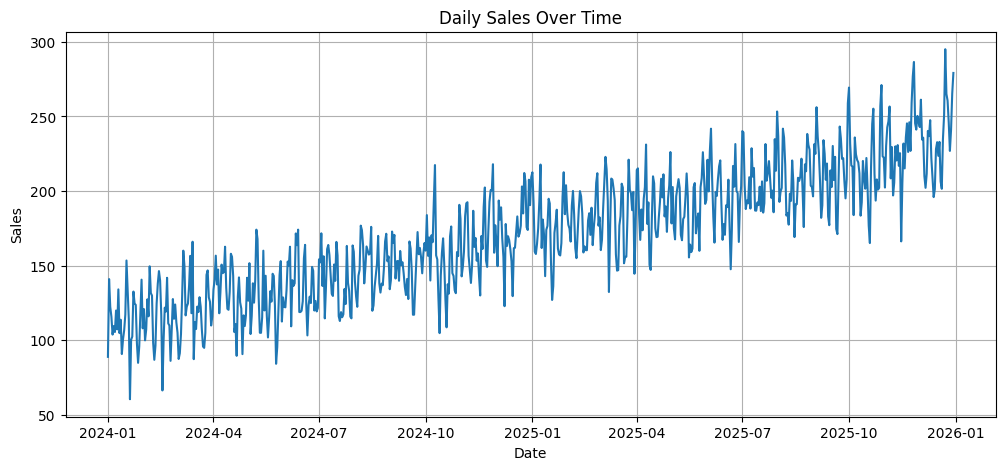

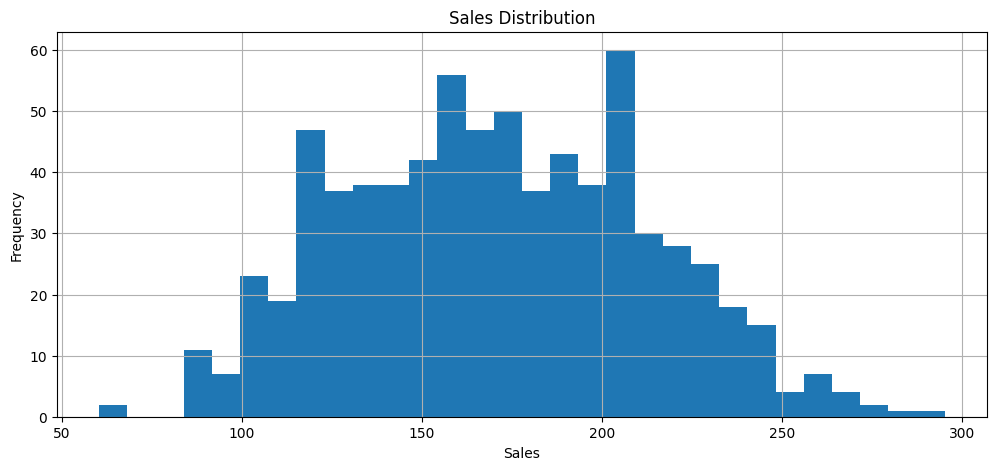

In [6]:

fig, ax = plt.subplots()
ax.plot(sales_df["date"], sales_df["sales"])
ax.set_title("Daily Sales Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.show()

fig, ax = plt.subplots()
ax.hist(sales_df["sales"], bins=30)
ax.set_title("Sales Distribution")
ax.set_xlabel("Sales")
ax.set_ylabel("Frequency")
plt.show()


## 7) Seasonal Decomposition

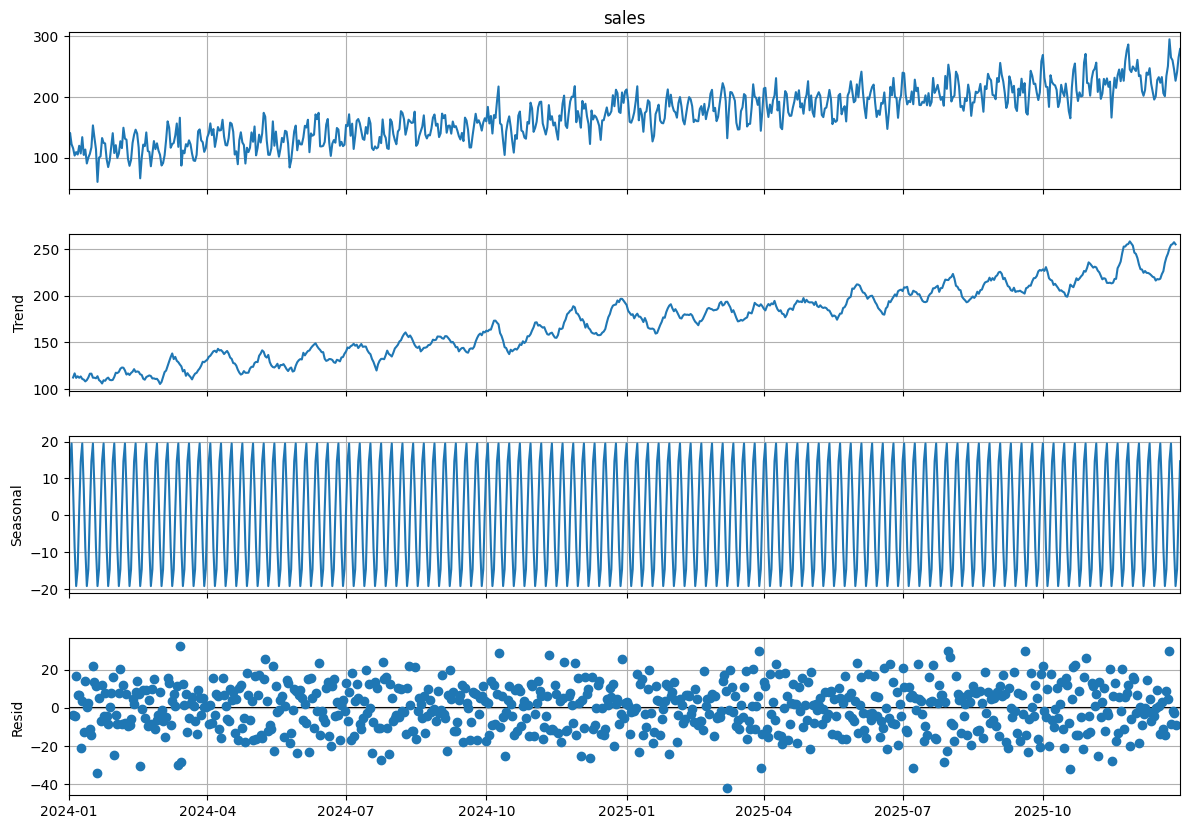

In [7]:

sales_series = sales_df.set_index("date")["sales"].asfreq("D")

if len(sales_series.dropna()) >= SEASONAL_PERIOD * 4:
    decomposition = seasonal_decompose(sales_series.interpolate(), model="additive", period=SEASONAL_PERIOD)
    fig = decomposition.plot()
    fig.set_size_inches(12, 9)
    plt.show()
else:
    print("Not enough data for seasonal decomposition.")


## 8) Train/Test Split for Forecasting

In [8]:

y = sales_df.set_index("date")["sales"].asfreq("D").interpolate()

exog_cols = [c for c in ["promo", "holiday", "weather_index"] if c in sales_df.columns]
X_exog = sales_df.set_index("date")[exog_cols].asfreq("D").fillna(0) if exog_cols else None

split_idx = int(len(y) * 0.85)
train_y, test_y = y.iloc[:split_idx], y.iloc[split_idx:]
train_X = X_exog.iloc[:split_idx] if X_exog is not None else None
test_X = X_exog.iloc[split_idx:] if X_exog is not None else None

print("Train size:", len(train_y))
print("Test size:", len(test_y))
print("Exogenous columns:", exog_cols)


Train size: 620
Test size: 110
Exogenous columns: ['promo', 'holiday', 'weather_index']


## 9) ARIMA Forecasting

ARIMA(5, 1, 0) MAE:  24.833
ARIMA(5, 1, 0) RMSE: 31.456
ARIMA(5, 1, 0) MAPE: 10.52%


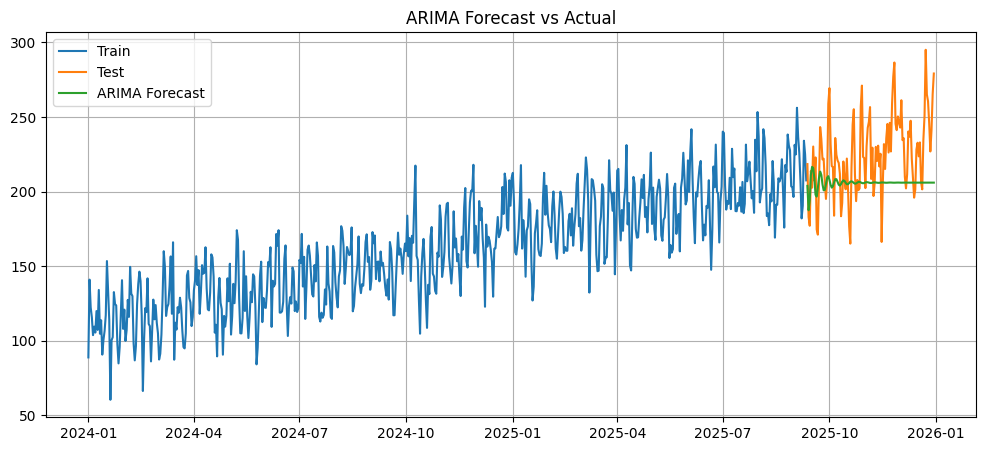

In [9]:

arima_order = (5, 1, 0)
arima_model = ARIMA(train_y, order=arima_order)
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test_y))
arima_mae = mean_absolute_error(test_y, arima_pred)
arima_rmse = rmse(test_y, arima_pred)
arima_mape = mape(test_y, arima_pred)

print(f"ARIMA{arima_order} MAE:  {arima_mae:.3f}")
print(f"ARIMA{arima_order} RMSE: {arima_rmse:.3f}")
print(f"ARIMA{arima_order} MAPE: {arima_mape:.2f}%")

fig, ax = plt.subplots()
ax.plot(train_y.index, train_y, label="Train")
ax.plot(test_y.index, test_y, label="Test")
ax.plot(test_y.index, arima_pred, label="ARIMA Forecast")
ax.set_title("ARIMA Forecast vs Actual")
ax.legend()
plt.show()


## 10) SARIMA Forecasting

SARIMA(1, 1, 1)x(1, 1, 1, 7) MAE:  16.550
SARIMA(1, 1, 1)x(1, 1, 1, 7) RMSE: 21.075
SARIMA(1, 1, 1)x(1, 1, 1, 7) MAPE: 7.16%


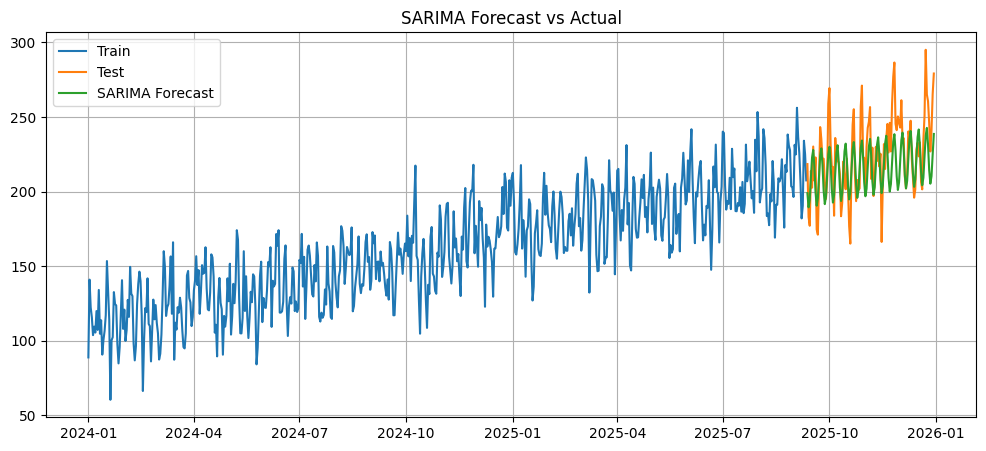

In [10]:

sarima_order = (1, 1, 1)
seasonal_order = (1, 1, 1, SEASONAL_PERIOD)

sarima_model = SARIMAX(
    train_y,
    order=sarima_order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=len(test_y))
sarima_mae = mean_absolute_error(test_y, sarima_pred)
sarima_rmse = rmse(test_y, sarima_pred)
sarima_mape = mape(test_y, sarima_pred)

print(f"SARIMA{sarima_order}x{seasonal_order} MAE:  {sarima_mae:.3f}")
print(f"SARIMA{sarima_order}x{seasonal_order} RMSE: {sarima_rmse:.3f}")
print(f"SARIMA{sarima_order}x{seasonal_order} MAPE: {sarima_mape:.2f}%")

fig, ax = plt.subplots()
ax.plot(train_y.index, train_y, label="Train")
ax.plot(test_y.index, test_y, label="Test")
ax.plot(test_y.index, sarima_pred, label="SARIMA Forecast")
ax.set_title("SARIMA Forecast vs Actual")
ax.legend()
plt.show()


## 11) SARIMAX Forecasting with External Drivers

SARIMAX MAE:  9.050
SARIMAX RMSE: 11.300
SARIMAX MAPE: 4.03%


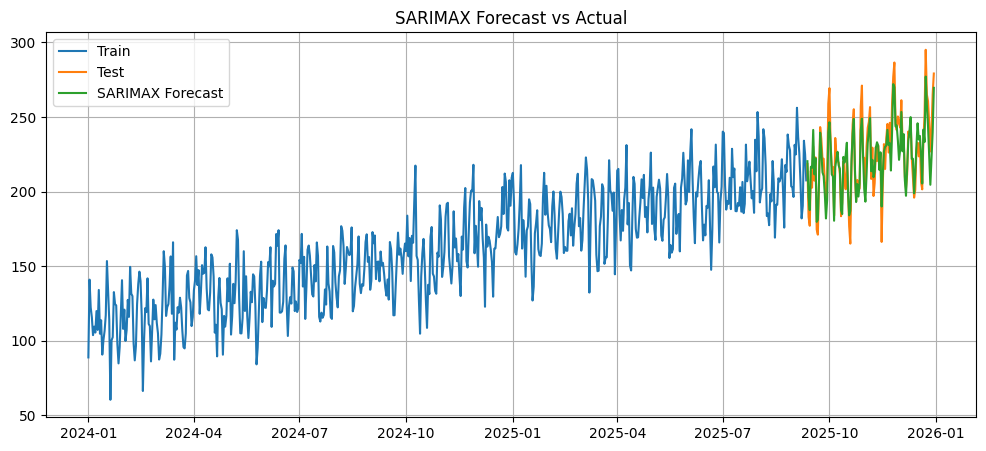

In [11]:

if exog_cols:
    sarimax_model = SARIMAX(
        train_y,
        exog=train_X,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarimax_fit = sarimax_model.fit(disp=False)
    sarimax_pred = sarimax_fit.forecast(steps=len(test_y), exog=test_X)

    sarimax_mae = mean_absolute_error(test_y, sarimax_pred)
    sarimax_rmse = rmse(test_y, sarimax_pred)
    sarimax_mape = mape(test_y, sarimax_pred)

    print(f"SARIMAX MAE:  {sarimax_mae:.3f}")
    print(f"SARIMAX RMSE: {sarimax_rmse:.3f}")
    print(f"SARIMAX MAPE: {sarimax_mape:.2f}%")

    fig, ax = plt.subplots()
    ax.plot(train_y.index, train_y, label="Train")
    ax.plot(test_y.index, test_y, label="Test")
    ax.plot(test_y.index, sarimax_pred, label="SARIMAX Forecast")
    ax.set_title("SARIMAX Forecast vs Actual")
    ax.legend()
    plt.show()
else:
    sarimax_pred = None
    sarimax_mae = sarimax_rmse = sarimax_mape = np.nan
    print("No exogenous features available for SARIMAX.")


## 12) Forecast Comparison and Winner Selection

In [12]:

results = pd.DataFrame([
    {"model": "ARIMA", "MAE": arima_mae, "RMSE": arima_rmse, "MAPE": arima_mape},
    {"model": "SARIMA", "MAE": sarima_mae, "RMSE": sarima_rmse, "MAPE": sarima_mape},
])

if sarimax_pred is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{"model": "SARIMAX", "MAE": sarimax_mae, "RMSE": sarimax_rmse, "MAPE": sarimax_mape}])
    ], ignore_index=True)

results = results.sort_values("RMSE").reset_index(drop=True)
results


,model,MAE,RMSE,MAPE
0,SARIMAX,9.049901,11.300500,4.032647
1,SARIMA,16.549826,21.074970,7.159667
2,ARIMA,24.833384,31.455692,10.524721


## 13) Final Refit on Full Data and Future Forecast

In [13]:

best_model_name = results.iloc[0]["model"]
print("Best model:", best_model_name)

full_y = y
full_X = X_exog

if best_model_name == "ARIMA":
    final_fit = ARIMA(full_y, order=arima_order).fit()
    future_forecast = final_fit.forecast(steps=FORECAST_HORIZON)

elif best_model_name == "SARIMA":
    final_fit = SARIMAX(
        full_y,
        order=sarima_order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    future_forecast = final_fit.forecast(steps=FORECAST_HORIZON)

else:
    final_fit = SARIMAX(
        full_y,
        exog=full_X,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    last_row = full_X.iloc[-1:]
    future_exog = pd.concat([last_row] * FORECAST_HORIZON, ignore_index=True)
    future_forecast = final_fit.forecast(steps=FORECAST_HORIZON, exog=future_exog)

forecast_index = pd.date_range(full_y.index.max() + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq="D")
forecast_df = pd.DataFrame({"date": forecast_index, "forecast_sales": np.asarray(future_forecast)})
forecast_df.head()


Best model: SARIMAX


,date,forecast_sales
0,2025-12-31,289.900475
1,2026-01-01,280.026317
2,2026-01-02,263.287759
3,2026-01-03,252.716162
4,2026-01-04,255.526278


## 14) Visualize Future Forecast

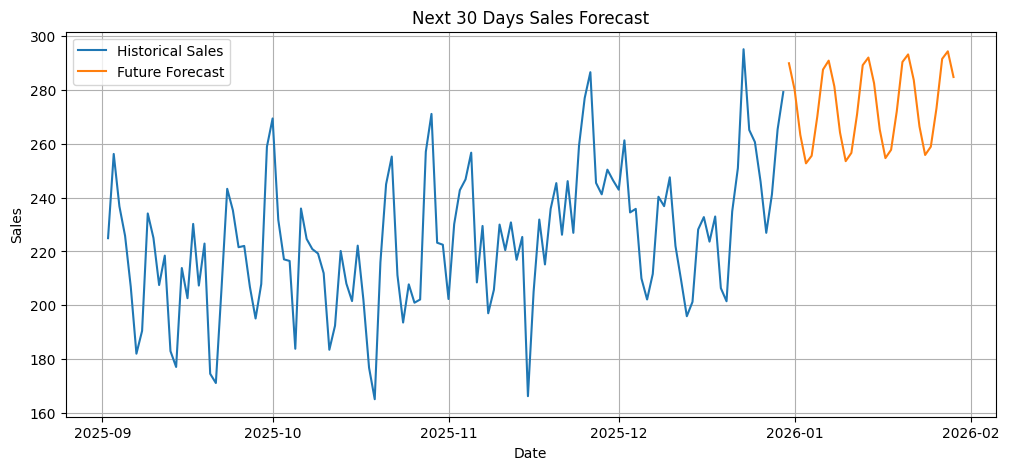

In [14]:

fig, ax = plt.subplots()
ax.plot(full_y.index[-120:], full_y.iloc[-120:], label="Historical Sales")
ax.plot(forecast_df["date"], forecast_df["forecast_sales"], label="Future Forecast")
ax.set_title("Next 30 Days Sales Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
plt.show()


## 15) Load and Prepare Review Data

In [15]:

reviews_df["review_comment"] = reviews_df["review_comment"].fillna("")
reviews_df["cleaned_text"] = reviews_df["review_comment"].apply(clean_text)

if "true_sentiment" not in reviews_df.columns:
    reviews_df["true_sentiment"] = "Neutral"

reviews_df.head()


,review_id,review_comment,true_sentiment,cleaned_text
0,1,Amazing product highly recommended,Positive,amazing product highly recommended
1,2,Excellent service and friendly staff,Positive,excellent service and friendly staff
2,3,Refund process was very slow,Negative,refund process was very slow
3,4,Very satisfied with the purchase,Positive,very satisfied with the purchase
4,5,Very satisfied with the purchase,Positive,very satisfied with the purchase


## 16) Sentiment Analysis with VADER

In [16]:

reviews_df["vader_score"] = reviews_df["cleaned_text"].apply(lambda x: sia.polarity_scores(x)["compound"])
reviews_df["vader_sentiment"] = reviews_df["vader_score"].apply(sentiment_label)

reviews_df[["review_comment", "cleaned_text", "vader_score", "vader_sentiment"]].head()


,review_comment,cleaned_text,vader_score,vader_sentiment
0,Amazing product highly recommended,amazing product highly recommended,0.7089,Positive
1,Excellent service and friendly staff,excellent service and friendly staff,0.7845,Positive
2,Refund process was very slow,refund process was very slow,0.0000,Neutral
3,Very satisfied with the purchase,very satisfied with the purchase,0.4754,Positive
4,Very satisfied with the purchase,very satisfied with the purchase,0.4754,Positive


## 17) Sentiment Quality Check

In [17]:

sentiment_summary = reviews_df["vader_sentiment"].value_counts().reset_index()
sentiment_summary.columns = ["sentiment", "count"]
sentiment_summary["share_%"] = (sentiment_summary["count"] / sentiment_summary["count"].sum() * 100).round(2)
sentiment_summary


,sentiment,count,share_%
0,Positive,574,57.4
1,Negative,228,22.8
2,Neutral,198,19.8


## 18) Supervised Text Classification

In [18]:

X_text = reviews_df["cleaned_text"].astype(str)
y_text = reviews_df["true_sentiment"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_text if y_text.nunique() > 1 else None
)

text_clf = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("lr", LogisticRegression(max_iter=2000))
])

text_clf.fit(X_train, y_train)
pred_text = text_clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred_text), 4))
print("F1 Macro:", round(f1_score(y_test, pred_text, average="macro"), 4))
print(classification_report(y_test, pred_text))


Accuracy: 1.0
F1 Macro: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        59
     Neutral       1.00      1.00      1.00        48
    Positive       1.00      1.00      1.00        93

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 19) Confusion Matrix

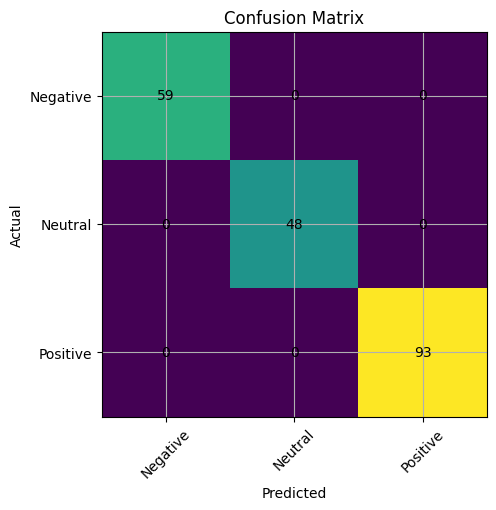

In [19]:

labels = sorted(y_text.unique())
cm = confusion_matrix(y_test, pred_text, labels=labels)

fig, ax = plt.subplots()
ax.imshow(cm)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


## 20) fastText-Ready Data Preparation

In [20]:

reviews_df["fasttext_line"] = "__label__" + reviews_df["true_sentiment"].astype(str) + " " + reviews_df["cleaned_text"].astype(str)

fasttext_path = OUTPUT_DIR / "fasttext_train.txt"
reviews_df["fasttext_line"].to_csv(fasttext_path, index=False, header=False)

print(f"Saved fastText training file to: {fasttext_path}")
reviews_df[["fasttext_line"]].head()


Saved fastText training file to: outputs\fasttext_train.txt


,fasttext_line
0,__label__Positive amazing product highly recom...
1,__label__Positive excellent service and friend...
2,__label__Negative refund process was very slow
3,__label__Positive very satisfied with the purc...
4,__label__Positive very satisfied with the purc...


## 21) Keyword and Theme Extraction

In [21]:

def top_words(series, n=20):
    vocab = TfidfVectorizer(stop_words="english", max_features=2000)
    mat = vocab.fit_transform(series.astype(str))
    scores = np.asarray(mat.sum(axis=0)).ravel()
    terms = np.array(vocab.get_feature_names_out())
    top_idx = np.argsort(scores)[::-1][:n]
    return pd.DataFrame({"term": terms[top_idx], "score": scores[top_idx]})

top_terms = top_words(reviews_df["cleaned_text"], n=15)
top_terms


,term,score
0,product,124.307576
1,delivery,86.133911
2,quality,66.211877
3,purchase,65.053824
4,satisfied,65.053824
5,buy,61.654185
6,love,61.654185
7,amazing,59.127802
8,highly,59.127802
9,recommended,59.127802


## 22) Review-Sales Insight Fusion

In [22]:

positive_share = (reviews_df["vader_sentiment"] == "Positive").mean() * 100
negative_share = (reviews_df["vader_sentiment"] == "Negative").mean() * 100

sales_change_pct = ((forecast_df["forecast_sales"].iloc[-1] - full_y.iloc[-1]) / full_y.iloc[-1]) * 100

insight_frame = pd.DataFrame([{
    "current_sales": round(float(full_y.iloc[-1]), 2),
    "forecast_sales_day_30": round(float(forecast_df["forecast_sales"].iloc[-1]), 2),
    "projected_change_%": round(float(sales_change_pct), 2),
    "positive_feedback_%": round(float(positive_share), 2),
    "negative_feedback_%": round(float(negative_share), 2),
}])

insight_frame


,current_sales,forecast_sales_day_30,projected_change_%,positive_feedback_%,negative_feedback_%
0,279.19,284.79,2.0,57.4,22.8


## 23) GenAI-Style Narrative Generator

In [23]:

def build_narrative_report(metrics_df, forecast_df, results_df, top_terms_df):
    best = results_df.iloc[0]
    current_sales = metrics_df["current_sales"].iloc[0]
    projected_sales = metrics_df["forecast_sales_day_30"].iloc[0]
    change_pct = metrics_df["projected_change_%"].iloc[0]
    pos = metrics_df["positive_feedback_%"].iloc[0]
    neg = metrics_df["negative_feedback_%"].iloc[0]

    top_terms = ", ".join(top_terms_df["term"].head(8).tolist())

    report = f"""
Executive Summary
-----------------
The strongest forecasting model in this run is {best['model']}, with RMSE {best['RMSE']:.3f} and MAPE {best['MAPE']:.2f}%.
Current sales are {current_sales:.2f}, and the 30-day forecast ends at {projected_sales:.2f}, indicating a projected change of {change_pct:.2f}%.
Customer feedback is {pos:.2f}% positive and {neg:.2f}% negative.

Interpretation
--------------
- The forecast suggests whether demand is rising, stable, or softening.
- Positive feedback likely reflects product quality, service, or delivery improvements.
- Negative feedback flags issues that can suppress future sales.

Key Demand Drivers
------------------
Frequently observed terms in customer feedback:
{top_terms}

Recommended Actions
-------------------
1. Increase inventory for products or periods where the forecast shows higher demand.
2. Investigate negative feedback themes and operational bottlenecks.
3. Use promo and holiday effects in planning if SARIMAX performs best.
4. Automate this report weekly for decision-makers.
"""
    return report.strip()

narrative_report = build_narrative_report(insight_frame, forecast_df, results, top_terms)
print(narrative_report)


Executive Summary
-----------------
The strongest forecasting model in this run is SARIMAX, with RMSE 11.300 and MAPE 4.03%.
Current sales are 279.19, and the 30-day forecast ends at 284.79, indicating a projected change of 2.00%.
Customer feedback is 57.40% positive and 22.80% negative.

Interpretation
--------------
- The forecast suggests whether demand is rising, stable, or softening.
- Positive feedback likely reflects product quality, service, or delivery improvements.
- Negative feedback flags issues that can suppress future sales.

Key Demand Drivers
------------------
Frequently observed terms in customer feedback:
product, delivery, quality, purchase, satisfied, buy, love, amazing

Recommended Actions
-------------------
1. Increase inventory for products or periods where the forecast shows higher demand.
2. Investigate negative feedback themes and operational bottlenecks.
3. Use promo and holiday effects in planning if SARIMAX performs best.
4. Automate this report weekly fo

## 24) Optional LLM Prompt Builder

In [24]:

def make_llm_prompt(narrative, results_df, insight_df):
    prompt = f"""
You are a retail analytics assistant.

Write a concise executive report based on:

Forecast model ranking:
{results_df.to_string(index=False)}

Business metrics:
{insight_df.to_string(index=False)}

Narrative draft:
{narrative}

Output format:
- Summary
- Forecast takeaway
- Customer sentiment takeaway
- Risks
- Actions
"""
    return prompt.strip()

llm_prompt = make_llm_prompt(narrative_report, results, insight_frame)
print(llm_prompt[:4000])


You are a retail analytics assistant.

Write a concise executive report based on:

Forecast model ranking:
  model       MAE      RMSE      MAPE
SARIMAX  9.049901 11.300500  4.032647
 SARIMA 16.549826 21.074970  7.159667
  ARIMA 24.833384 31.455692 10.524721

Business metrics:
 current_sales  forecast_sales_day_30  projected_change_%  positive_feedback_%  negative_feedback_%
        279.19                 284.79                 2.0                 57.4                 22.8

Narrative draft:
Executive Summary
-----------------
The strongest forecasting model in this run is SARIMAX, with RMSE 11.300 and MAPE 4.03%.
Current sales are 279.19, and the 30-day forecast ends at 284.79, indicating a projected change of 2.00%.
Customer feedback is 57.40% positive and 22.80% negative.

Interpretation
--------------
- The forecast suggests whether demand is rising, stable, or softening.
- Positive feedback likely reflects product quality, service, or delivery improvements.
- Negative feedback flag

## 25) Save All Outputs

In [25]:

forecast_file = OUTPUT_DIR / "sales_forecast.csv"
reviews_file = OUTPUT_DIR / "reviews_classified.csv"
metrics_file = OUTPUT_DIR / "model_metrics.csv"
report_file = OUTPUT_DIR / "executive_report.txt"

forecast_df.to_csv(forecast_file, index=False)
reviews_df.to_csv(reviews_file, index=False)
results.to_csv(metrics_file, index=False)
Path(report_file).write_text(narrative_report, encoding="utf-8")

print("Saved:")
print(f"- {forecast_file}")
print(f"- {reviews_file}")
print(f"- {metrics_file}")
print(f"- {report_file}")


Saved:
- outputs\sales_forecast.csv
- outputs\reviews_classified.csv
- outputs\model_metrics.csv
- outputs\executive_report.txt


## 26) End-to-End Workflow Summary

This notebook now includes a full pipeline from raw data to insights:

- sales loading or demo-data generation
- cleaning, visualizing, and decomposing the time series
- ARIMA / SARIMA / SARIMAX comparison
- future sales forecasting
- NLP preprocessing
- VADER sentiment scoring
- supervised text classification
- fastText export
- narrative report generation
- saved outputs for deployment
